In [1]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from Fastkan import FastKAN

In [2]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

# Loading Pavia Univeristy Dataset

In [3]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :no_of_bands]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [4]:
#Normalizing the image
max_val = np.max(image)
normalized_image = image.astype(np.float32) / max_val

In [5]:
image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


#   Dataset for Training 

In [6]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(42776, 66)


In [7]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(42776,)

# Model Defination

In [8]:
class ColorFastKAN(nn.Module):

    def __init__( self, no_of_bands,number_of_primitives,output_classes,):
        super().__init__()
        self.primitives = nn.ModuleList([
            FastKAN(
                layers_hidden=[no_of_bands, 1])
            for _ in range(number_of_primitives)
        ])
        self.classifier_kan = FastKAN(layers_hidden =[number_of_primitives,output_classes], )

    def forward(self, x):
        primitive_outputs = [
            primitive(x)
            for primitive in self.primitives]
        merged = torch.cat(primitive_outputs ,dim=1)
        kan_logits = self.classifier_kan(merged)
        return kan_logits

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = ColorFastKAN(no_of_bands=no_of_bands,number_of_primitives=number_of_primitives,output_classes=output_classes).to(device)

Using device: cpu


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters())


In [10]:
print(model)

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=24, out_features=9, bias=False)
        (base_linear): Linear(in_features=3, out_features=9, bias=True)
      )
    )
  )
)


In [11]:
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

summary(
    model,
    input_size=(1, no_of_bands))

optimizer = torch.optim.Adam(
    model.parameters(),)

criterion = nn.CrossEntropyLoss()

x_tensor = torch.tensor( x,dtype=torch.float32)

y_tensor = torch.tensor( y,dtype=torch.long)

batch_size = 32

dataset = TensorDataset(x_tensor,y_tensor)

train_loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output,batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = torch.argmax(output,dim=1)

        total_correct += ( predictions == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples

    epoch_accuracy = (total_correct / total_samples
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{no_of_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Using device: cpu
Epoch [1/30] | Loss: 0.9685 | Accuracy: 0.6723
Epoch [2/30] | Loss: 0.6356 | Accuracy: 0.7787
Epoch [3/30] | Loss: 0.6065 | Accuracy: 0.7855
Epoch [4/30] | Loss: 0.5833 | Accuracy: 0.7923
Epoch [5/30] | Loss: 0.5878 | Accuracy: 0.7907
Epoch [6/30] | Loss: 0.5668 | Accuracy: 0.7975
Epoch [7/30] | Loss: 0.5569 | Accuracy: 0.8001
Epoch [8/30] | Loss: 0.5800 | Accuracy: 0.7960
Epoch [9/30] | Loss: 0.5505 | Accuracy: 0.8029
Epoch [10/30] | Loss: 0.5385 | Accuracy: 0.8079
Epoch [11/30] | Loss: 0.5313 | Accuracy: 0.8092
Epoch [12/30] | Loss: 0.5316 | Accuracy: 0.8099
Epoch [13/30] | Loss: 0.5208 | Accuracy: 0.8146
Epoch [14/30] | Loss: 0.5156 | Accuracy: 0.8175
Epoch [15/30] | Loss: 0.5075 | Accuracy: 0.8214
Epoch [16/30] | Loss: 0.5071 | Accuracy: 0.8202
Epoch [17/30] | Loss: 0.5013 | Accuracy: 0.8240
Epoch [18/30] | Loss: 0.4926 | Accuracy: 0.8263
Epoch [19/30] | Loss: 0.4899 | Accuracy: 0.8267
Epoch [20/30] | Loss: 0.4941 | Accuracy: 0.8246
Epoch [21/30] | Loss: 0.4933 | 

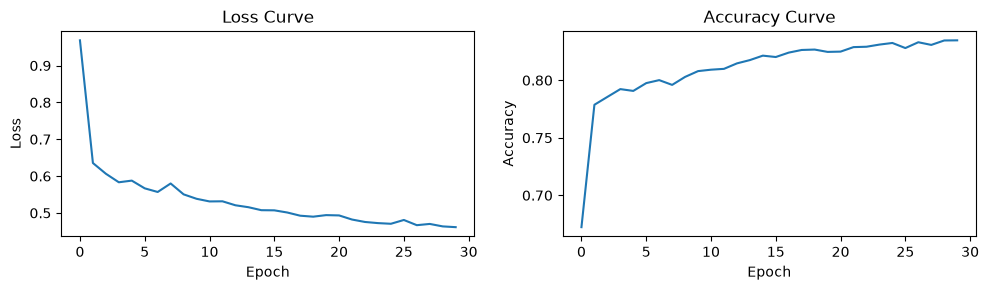

In [12]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Plot each learned Filters

In [13]:
wavelength = np.linspace(430, 860, no_of_bands) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


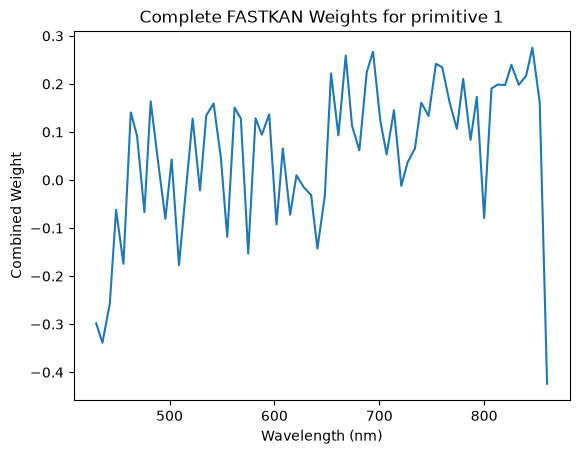

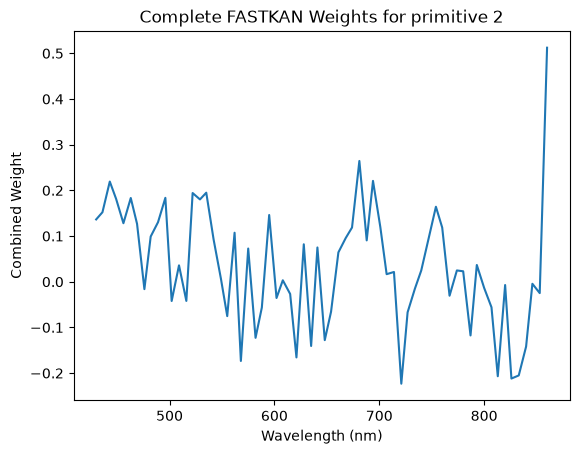

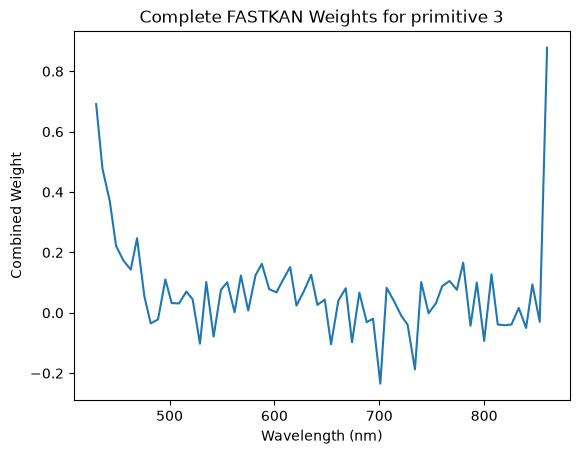

In [14]:
primitive_curves = []
input_data = torch.tensor(x , dtype=torch.float32 , device=device)

for primitive_no in range(number_of_primitives):

    layer= model.primitives[primitive_no].layers[0] 

    with torch.no_grad():
        # base contribution
        base_input = layer.base_activation(input_data)
        base_contribution = (base_input*layer.base_linear.weight)
        # spline contribution
        normalized =layer.layernorm(input_data)
        spline_basis =layer.rbf(normalized)
        num_grids = layer.rbf.grid.numel()
        spline_weights = (layer.spline_linear.weight.reshape(1, no_of_bands , num_grids))
        spline_contribution =(spline_basis*spline_weights).sum(dim=2)
        complete_contribution = base_contribution + spline_contribution
        p = complete_contribution.mean(dim=0)
    p=p.cpu().numpy()
    primitive_curves.append(p)

    plt.plot(wavelength_int,p)

    plt.title(f"Complete FASTKAN Weights for primitive {primitive_no + 1}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Combined Weight")

    plt.show()

In [15]:
for i ,p in enumerate(primitive_curves):
    print(i+1, f"primitive_{i+1}" , p[0])

1 primitive_1 -0.29815257
2 primitive_2 0.13639985
3 primitive_3 0.6911615


In [16]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

0 primitives.0.layers.0.layernorm.weight torch.Size([66])
1 primitives.0.layers.0.layernorm.bias torch.Size([66])
2 primitives.0.layers.0.spline_linear.weight torch.Size([1, 528])
3 primitives.0.layers.0.base_linear.weight torch.Size([1, 66])
4 primitives.0.layers.0.base_linear.bias torch.Size([1])
5 primitives.1.layers.0.layernorm.weight torch.Size([66])
6 primitives.1.layers.0.layernorm.bias torch.Size([66])
7 primitives.1.layers.0.spline_linear.weight torch.Size([1, 528])
8 primitives.1.layers.0.base_linear.weight torch.Size([1, 66])
9 primitives.1.layers.0.base_linear.bias torch.Size([1])
10 primitives.2.layers.0.layernorm.weight torch.Size([66])
11 primitives.2.layers.0.layernorm.bias torch.Size([66])
12 primitives.2.layers.0.spline_linear.weight torch.Size([1, 528])
13 primitives.2.layers.0.base_linear.weight torch.Size([1, 66])
14 primitives.2.layers.0.base_linear.bias torch.Size([1])
15 classifier_kan.layers.0.layernorm.weight torch.Size([3])
16 classifier_kan.layers.0.layernor

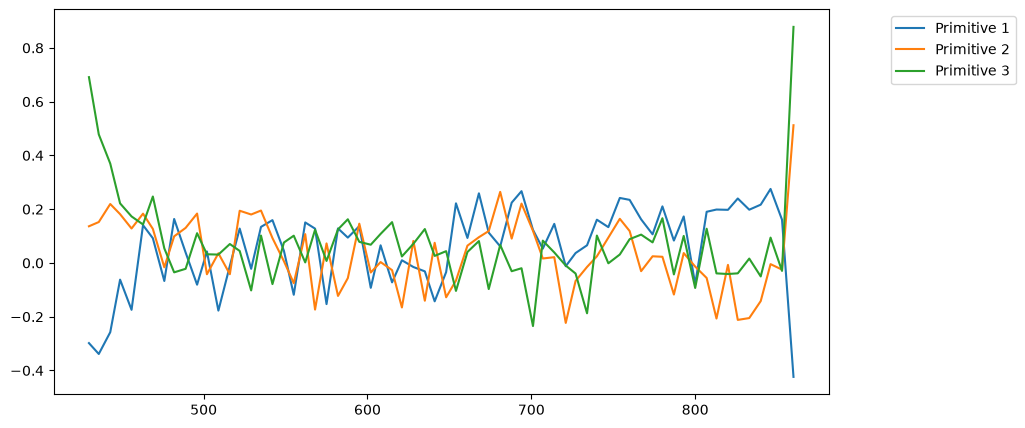

In [17]:
plt.figure(figsize=(10, 5))

for primitive_no in range(number_of_primitives):

    plt.plot(wavelength_int[:no_of_bands],primitive_curves[primitive_no],label=f"Primitive {primitive_no + 1}")
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()


In [18]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')

In [19]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [20]:
torch.save(model.state_dict(), f"{model_name}.pth")

In [21]:
model = ColorFastKAN(
    no_of_bands,
    number_of_primitives,
    output_classes
)

model.load_state_dict(torch.load(f"{model_name}.pth"))
model.eval()

ColorFastKAN(
  (primitives): ModuleList(
    (0-2): 3 x FastKAN(
      (layers): ModuleList(
        (0): Fast_KANLinear(
          (layernorm): LayerNorm((66,), eps=1e-05, elementwise_affine=True)
          (rbf): RadialBasisFunction()
          (spline_linear): SplineLinear(in_features=528, out_features=1, bias=False)
          (base_linear): Linear(in_features=66, out_features=1, bias=True)
        )
      )
    )
  )
  (classifier_kan): FastKAN(
    (layers): ModuleList(
      (0): Fast_KANLinear(
        (layernorm): LayerNorm((3,), eps=1e-05, elementwise_affine=True)
        (rbf): RadialBasisFunction()
        (spline_linear): SplineLinear(in_features=24, out_features=9, bias=False)
        (base_linear): Linear(in_features=3, out_features=9, bias=True)
      )
    )
  )
)

#Generate Image

In [22]:
def predict_image():
    x_pred = image_for_training.reshape(-1, no_of_bands)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor( x_pred,dtype=torch.float32, device=device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = []

        for primitive in model.primitives:
            primitive_outputs.append(primitive(x_pred))
        prediction = torch.cat(primitive_outputs,dim=1)

    prediction = prediction.cpu().numpy()

    predicted_image = prediction.reshape(
        image.shape[0],
        image.shape[1],
        number_of_primitives
    )

    return predicted_image
def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    if max_val == 0:
        min_max_normalized_image = predicted_image.copy()
    else:
        min_max_normalized_image = predicted_image / max_val
    normalized_channel_image = np.zeros_like(predicted_image)

    for i in range(predicted_image.shape[-1]):

        channel = predicted_image[:, :, i]

        channel_max = np.max(np.abs(channel))

        if channel_max != 0:
            normalized_channel_image[:, :, i] = (
                channel / channel_max
            )
        else:
            normalized_channel_image[:, :, i] = channel
    clipped_image = np.clip(
        predicted_image,0,1)
    c1, c2, c3 = [c - 1 for c in channels]

    rgb_minmax = np.dstack((
        min_max_normalized_image[:, :, c1],
        min_max_normalized_image[:, :, c2],
        min_max_normalized_image[:, :, c3]
    ))

    rgb_channelwise = np.dstack((
        normalized_channel_image[:, :, c1],
        normalized_channel_image[:, :, c2],
        normalized_channel_image[:, :, c3]
    ))

    rgb_clipped = np.dstack((
        clipped_image[:, :, c1],
        clipped_image[:, :, c2],
        clipped_image[:, :, c3]
    ))

    return [
        rgb_minmax,
        rgb_channelwise,
        rgb_clipped
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4960933..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8742287].


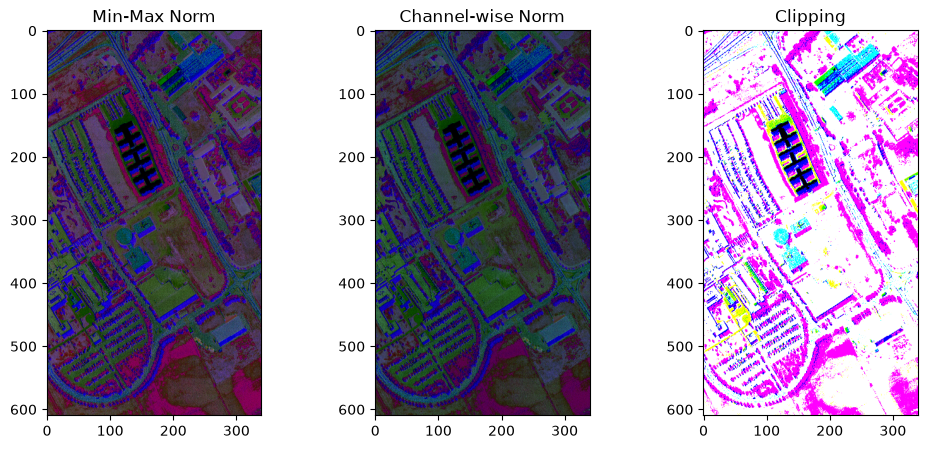

In [23]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Min-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()